# YOLO 目标检测入门教程

我们将使用 [Ultralytics](https://github.com/ultralytics/ultralytics) 库来运行 YOLO 模型。

In [ ]:
# 1. 安装 Ultralytics 库
!pip install ultralytics

接下来，我们加载一个预训练的 YOLOv8 纳米级（nano）模型，它速度很快，适合在 CPU 或轻量级 GPU 上运行。

In [2]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

# 2. 加载预训练模型 (会自动下载权重文件)
model = YOLO('yolov8n.pt')

print("模型加载成功！")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
模型加载成功！


现在我们使用一张网上的图片来测试检测效果。


image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 43.7ms
Speed: 1.9ms preprocess, 43.7ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 480)


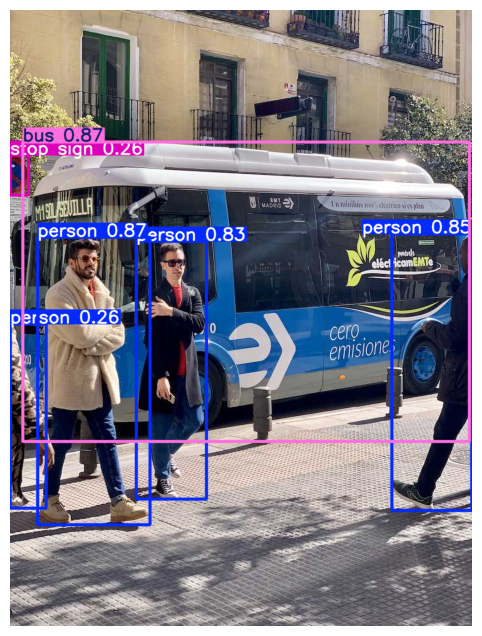

In [3]:
# 3. 运行推理
# 我们可以直接传入图片的 URL
results = model.predict(source='https://ultralytics.com/images/bus.jpg', save=False)

# 4. 可视化结果
for r in results:
    # 将结果转换为 BGR 图像（OpenCV 格式）并显示
    im_array = r.plot()  # 绘制检测框的图像
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

### 尝试最新的 YOLO26 模型
我们可以简单的更换模型名称来加载最新版的模型。


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 378.0ms
Speed: 1.5ms preprocess, 378.0ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 480)


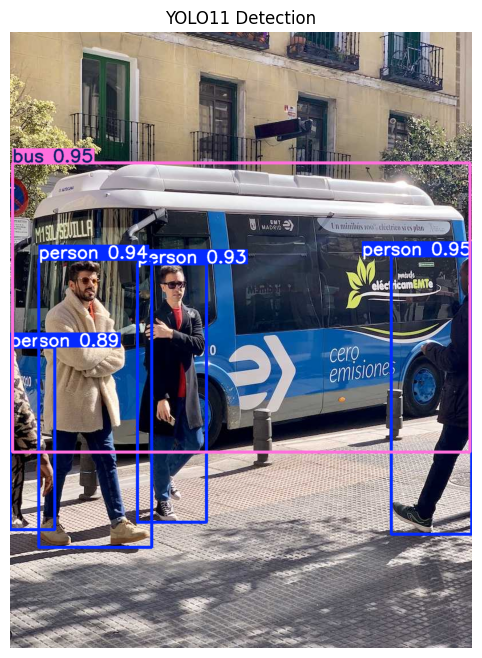

In [15]:
# 加载最新的 YOLO26
model_v11 = YOLO('yolo26l.pt')

# 运行推理
results_v11 = model_v11.predict(source='https://ultralytics.com/images/bus.jpg')

# 可视化
for r in results_v11:
    im_array = r.plot()
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB))
    plt.title("YOLO11 Detection")
    plt.axis('off')
    plt.show()

### 查看模型支持的识别类别
YOLO 预训练模型通常支持 80 种常见物体。我们可以通过 `model.names` 查看完整列表。

In [6]:
# 查看模型可以识别的所有类别名称
print(f"该模型共支持 {len(model.names)} 个类别：")
print(model.names)

该模型共支持 80 个类别：
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phon

### 进阶：精细化控制推理参数
通过参数，我们可以让模型只输出我们感兴趣的内容。


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 3 persons, 1 bus, 29.0ms
Speed: 1.6ms preprocess, 29.0ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 480)


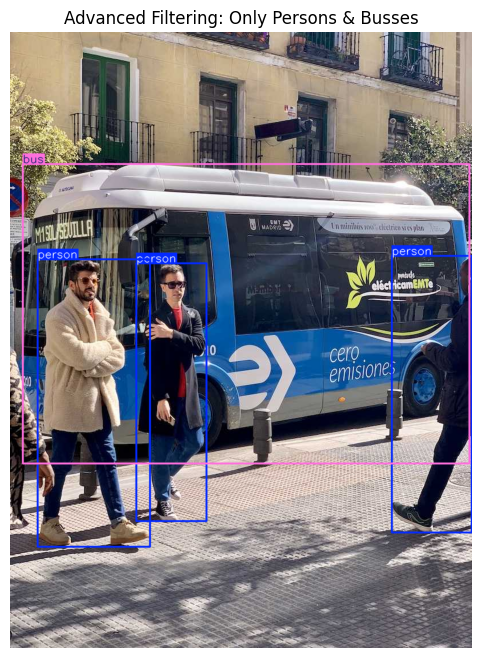

In [19]:
# 进阶推理演示
results_advanced = model.predict(
    source='https://ultralytics.com/images/bus.jpg',
    conf=0.5,        # 只显示置信度大于 0.5 的结果
    classes=[0, 5],   # 只检测 'person' (0) 和 'bus' (5)
    save=False
)

for r in results_advanced:
    # 修改可视化参数：线条更细 (line_width)，不显示概率值 (conf=False)
    im_array = r.plot(line_width=2, conf=False)

    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB))
    plt.title("Advanced Filtering: Only Persons & Busses")
    plt.axis('off')
    plt.show()

此外，你还可以尝试将结果保存为 JSON 或 CSV 格式进行二次开发。如果你想在本地视频或者摄像头上运行，只需要把 `source` 换成视频文件路径或 `0`（摄像头 ID）即可。

### 视频实时检测 Demo
由于 Colab 是基于浏览器的，我们使用 `IPython.display` 来实现平滑的实时刷新效果。

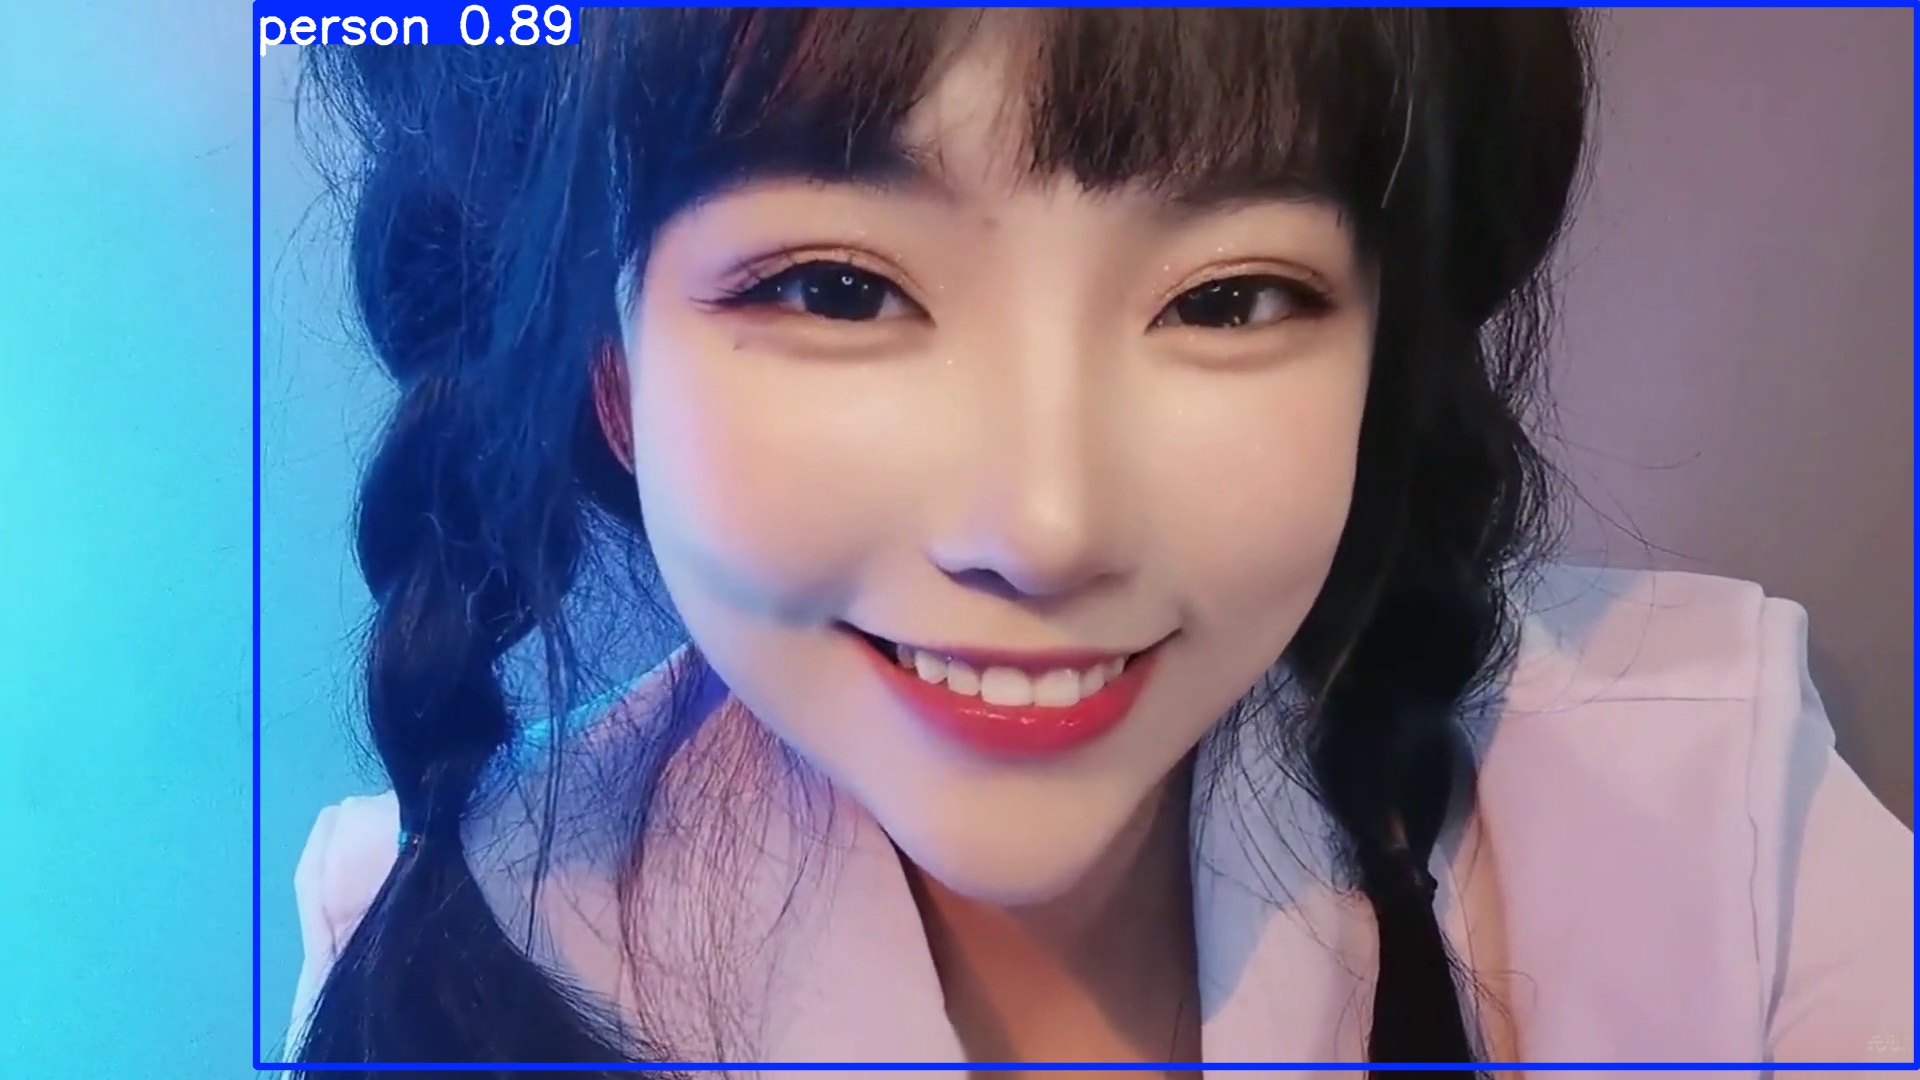

正在播放第 153 帧 (尝试减少白屏感)
资源已释放


In [39]:
import cv2
import os
import numpy as np
from ultralytics import YOLO
from IPython.display import display, Image, clear_output
import time

# 设置视频路径
source_path = '/content/my_vedio.mp4'
model = YOLO('yolov8n.pt')

if os.path.exists(source_path):
    cap = cv2.VideoCapture(source_path)

    # 获取视频宽高用于创建黑屏背景
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    black_screen = np.zeros((height, width, 3), dtype=np.uint8)

    try:
        frame_count = 0
        while cap.isOpened():
            success, frame = cap.read()
            if not success:
                break

            # 每 3 帧处理一次
            if frame_count % 3 == 0:
                results = model.predict(frame, conf=0.3, verbose=False)
                annotated_frame = results[0].plot()

                # 编码为 JPG
                _, buffer = cv2.imencode('.jpg', annotated_frame)

                clear_output(wait=True)
                # 此时 Colab 渲染机制仍可能导致短暂白场，但在某些环境下显示黑色背景数据会有所改善
                display(Image(data=buffer.tobytes()))

                print(f"正在播放第 {frame_count} 帧 (尝试减少白屏感)")
                time.sleep(0.05)

            frame_count += 1

    except KeyboardInterrupt:
        print("播放已停止")
    finally:
        cap.release()
        print("资源已释放")
else:
    print(f"未找到文件: {source_path}")

### 方案：保存为平滑视频并播放
我们将处理后的结果保存为 `output.mp4`，这样可以彻底消除实时刷新带来的闪烁感。

In [43]:
import cv2
import os
from ultralytics import YOLO

# 1. 配置路径
source_path = '/content/my_vedio.mp4'
output_path = '/content/output_processed.mp4'
temp_path = '/content/temp.mp4' # 用于转换编码以便浏览器播放

model = YOLO('yolo26l.pt')
cap = cv2.VideoCapture(source_path)

# 2. 获取视频属性
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

# 3. 创建视频写入对象
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

print("正在处理视频并保存到文件，请稍候...")
frame_count = 0
while cap.isOpened():
    success, frame = cap.read()
    if not success: break

    # 全量推理
    results = model.predict(frame, verbose=False)
    annotated_frame = results[0].plot()

    # 写入文件
    out.write(annotated_frame)
    frame_count += 1
    if frame_count % 30 == 0: print(f"已处理 {frame_count} 帧...")

cap.release()
out.release()
print("处理完成！正在转换编码以支持浏览器播放...")

# 4. 使用 ffmpeg 转换为 H.264 编码（浏览器通用）
!ffmpeg -y -i {output_path} -vcodec libx264 {temp_path} -loglevel quiet

print("全部就绪，请运行下方单元格查看视频。")

正在处理视频并保存到文件，请稍候...
已处理 30 帧...
已处理 60 帧...
已处理 90 帧...
已处理 120 帧...
已处理 150 帧...
处理完成！正在转换编码以支持浏览器播放...
全部就绪，请运行下方单元格查看视频。


In [44]:
from IPython.display import HTML
from base64 import b64encode

# 读取转换后的视频并嵌入到 HTML 播放器中
mp4 = open('/content/temp.mp4','rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""
<video width="800" controls>
      <source src="{data_url}" type="video/mp4">
</video>
""")